# **Проект команды №6**
**Авторы:** Начинова Мария, Соколов Кирилл

*Данная работа выполнена следующим образом:*

1. **Часть I** (Начинова М.)  
2. **Часть II** (Соколов К.)  
3. **Часть III** (Совместная работа)

# **Часть I (Начинова М.)**
В этой части работы я сосредоточилась на разработке и тестировании различных архитектур свёрточных нейронных сетей для задачи классификации фейковых и реальных лиц. Основная цель - изучить, как различные модификации и техники влияют на качество модели.

### **Эксперимент 1: Базовая cnn архитектура**

**Цель:** Создать и обучить простую модель, чтобы понять сложность задачи и получить точку отсчёта.

**Подготовка данных**

Перед началом экспериментов была проведена стандартная подготовка данных:

* Загрузка и распаковка датасета.

* Анализ распределения классов: обнаружен значительный дисбаланс (примерно 35 000 реальных и 15 000 фейковых изображений).

* Разделение данных на обучающую (40 000 изображений) и валидационную (10 000 изображений) выборки с сохранением пропорций классов.

* Создание DataLoader с применением WeightedRandomSampler для компенсации дисбаланса на этапе обучения.

* Использование аугментаций для обучающей выборки (случайные повороты, отражения, изменение яркости/контраста) для улучшения обобщающей способности модели.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import f1_score, recall_score, precision_score

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/ml-intensive-yandex-academy-autumn-2025.zip"

if os.path.exists(zip_path):
  with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/data')
  print(f"все загрузилось, ура!")
else:
    print("зипка не найдена")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
все загрузилось, ура!


In [ ]:
base = Path('/content/data/dataset')
train_path = base / 'train_images'
test_path = base / 'test_images'
csv_path = base / 'train_solution.csv'

print(f"train images: {train_path.exists()}")
print(f"yest images: {test_path.exists()}")
print(f"csv: {csv_path.exists()}")


train images: True
yest images: True
csv: True


настоящих: 41500
фейковых: 8500
всего: 50000


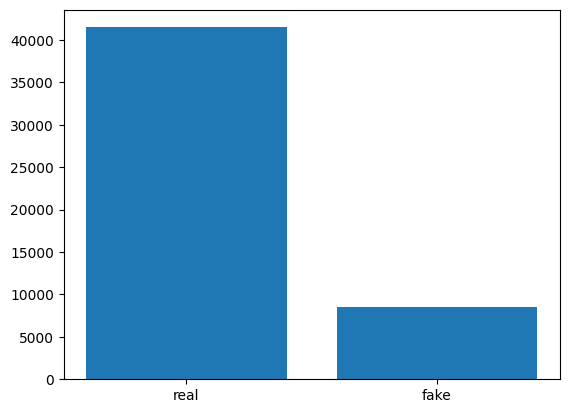

In [ ]:
labels_df = pd.read_csv(csv_path, header=None, names=['Id', 'target_feature'])

real = sum(labels_df['target_feature'] == 0)
fake = sum(labels_df['target_feature'] == 1)

print(f"настоящих: {real}")
print(f"фейковых: {fake}")
print(f"всего: {real + fake}")

plt.bar(['real', 'fake'], [real, fake])
plt.show()

In [ ]:
class FaceDataset(Dataset):
  def __init__(self, img_dir, labels=None, transform=None, train=True):
    self.img_dir = img_dir
    self.transform = transform
    self.train = train

    if train and labels is not None:
      self.ids = labels['Id'].tolist()
      self.labels = labels['target_feature'].tolist()
    else:
      self.ids = [int(f.stem) for f in img_dir.glob("*.*")
                 if f.suffix in ['.jpg', '.png', '.jpeg']]
      self.labels = None

  def __len__(self):
    return len(self.ids)

  def __getitem__(self, idx):
    img_id = self.ids[idx]

    for ext in ['.jpg', '.png', '.jpeg']:
      path = self.img_dir / f"{img_id}{ext}"
      if path.exists():
        img = Image.open(path).convert('RGB')
        break

    if self.transform:
      img = self.transform(img)

    if self.train:
      return img, torch.tensor(self.labels[idx], dtype=torch.float32)
    return img, img_id

In [ ]:
train_transform = transforms.Compose([
  transforms.Resize((256, 256)),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.ToTensor(),
  transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

val_transform = transforms.Compose([
  transforms.Resize((256, 256)),
  transforms.ToTensor(),
  transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

train_df, val_df = train_test_split(
  labels_df,
  test_size=0.2,
  random_state=42,
  stratify=labels_df['target_feature'])

print(f"train: {len(train_df)}, val: {len(val_df)}")

train_dataset = FaceDataset(train_path, train_df, train_transform, True)
val_dataset = FaceDataset(train_path, val_df, val_transform, True)

train: 40000, val: 10000


In [ ]:
from torch.utils.data import WeightedRandomSampler

real_count_train = len(train_df[train_df['target_feature'] == 0])
fake_count_train = len(train_df[train_df['target_feature'] == 1])
print(f"в обучающей выборке: {real_count_train} реальных, {fake_count_train} фейков")

sample_weights = []
for label in train_df['target_feature']:
    if label == 1:
        sample_weights.append(real_count_train / fake_count_train)
    else:
        sample_weights.append(1.0)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=4,
    pin_memory=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True)

In [ ]:
class FaceCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),)

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512 * 16 * 16, 512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 1))

  def forward(self, x):
    return self.classifier(self.features(x))

model = FaceCNN().to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    model.to(device)

print(f"параметров: {sum(p.numel() for p in model.parameters()):,}")


параметров: 68,662,785


In [ ]:
class FaceCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),)

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512 * 16 * 16, 512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 1))

  def forward(self, x):
    return self.classifier(self.features(x))

model = FaceCNN().to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    model.to(device)

print(f"параметров: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
pos_weight_value = torch.tensor([real_count_train / fake_count_train]).to(device)
print(f"pos_weight для класса 1 (фейки): {pos_weight_value.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_f1 = 0

for epoch in range(15):
  model.train()
  train_loss = train_correct = train_total = 0

  for images, labels in tqdm(train_loader, desc=f"эпоха {epoch+1}"):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs.squeeze(), labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    threshold = 0.3
    preds = (torch.sigmoid(outputs) > threshold).float().squeeze()

    train_correct += (preds == labels).sum().item()
    train_total += labels.size(0)

  model.eval()
  val_loss = val_correct = val_total = 0
  all_preds, all_labels = [], []

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs.squeeze(), labels)

      val_loss += loss.item()

      threshold = 0.3
      preds = (torch.sigmoid(outputs) > threshold).float().squeeze()

      val_correct += (preds == labels).sum().item()
      val_total += labels.size(0)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  train_losses.append(train_loss / len(train_loader))
  val_losses.append(val_loss / len(val_loader))
  train_accs.append(train_correct / train_total)
  val_accs.append(val_correct / val_total)

  f1 = f1_score(all_labels, all_preds, zero_division=0)

  recall = recall_score(all_labels, all_preds, zero_division=0)
  precision = precision_score(all_labels, all_preds, zero_division=0)

  print(f"loss: {train_losses[-1]:.3f}/{val_losses[-1]:.3f} | "
        f"acc: {train_accs[-1]:.3f}/{val_accs[-1]:.3f} | "
        f"f1: {f1:.3f} | recall: {recall:.3f} | precision: {precision:.3f}")

  if f1 > best_f1:
    best_f1 = f1
    torch.save(model.state_dict(), 'best_model.pth')
    print(f"сохранена лучшая моделька (F1: {f1:.3f})")

print(f"лучший f1: {best_f1:.3f}")

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_losses, 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('потери при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_accs, 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('accuracy')
plt.title('точность при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
submission3 = pd.DataFrame({
    'id': range(len(test_predictions)),
    'target_feature': test_predictions
})

output_file = 'submission3.csv'
submission3.to_csv(output_file, index=False)

print(f"файл сохранен: {output_file}")

**Архитектура:**

* Свёрточный блок: 4 последовательных слоя Conv2d (64, 128, 256, 512 фильтров), каждый с BatchNorm, ReLU и MaxPooling.

* Классификатор: Полносвязные слои (512 - 512 - 1 нейрон).

* Активация: Sigmoid для получения вероятности принадлежности к классу "фейк".

* Количество параметров: ~68.6 млн.

**Обучение:**

* Функция потерь: BCEWithLogitsLoss с весами для положительного класса.

* Оптимизатор: Adam (learning rate = 0.001).

* Эпохи: 15.

**Итоговые метрики на валидации:**

* loss: 0.304/0.395

* acc: 0.946/0.911

* f1: 0.783

* recall: 0.944

* precision: 0.670

* лучший f1: 0.810

**Public Score на Kaggle:** 0.49770

**Вывод:** Базовая модель показала неплохую точность (accuracy), но низкий F1-score и скор на лидерборде, что указывает на недостаточную способность отличать фейковые лица от реальных, особенно на несбалансированных данных.

### **Эксперимент 2: Улучшенная CNN с частотным анализом и Focal Loss**
**Цель:** Улучшить качество модели за счёт внедрения дополнительных признаков и более сложной функции потерь.

In [ ]:
import cv2
from scipy import fftpack

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [ ]:
def compute_frequency_channel(image_tensor):
    batch_size, channels, height, width = image_tensor.shape
    freq_channels = []

    for i in range(batch_size):
        img_gray = image_tensor[i, 1, :, :].cpu().numpy()

        fft = fftpack.fft2(img_gray)
        fft_shifted = fftpack.fftshift(fft)

        magnitude = np.log(np.abs(fft_shifted) + 1)

        magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)

        magnitude_tensor = torch.from_numpy(magnitude).float().unsqueeze(0)
        freq_channels.append(magnitude_tensor)

    return torch.stack(freq_channels).to(image_tensor.device)

In [ ]:
train_transform_enhanced = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

val_transform_enhanced = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

train_dataset_enhanced = FaceDataset(train_path, train_df, train_transform_enhanced, True)
val_dataset_enhanced = FaceDataset(train_path, val_df, val_transform_enhanced, True)

real_count_train = len(train_df[train_df['target_feature'] == 0])
fake_count_train = len(train_df[train_df['target_feature'] == 1])
total_samples = len(train_df)

In [ ]:
class_weights = [
    1.0 if label == 0 else real_count_train / fake_count_train
    for label in train_df['target_feature']]

sampler_enhanced = WeightedRandomSampler(
    weights=class_weights,
    num_samples=len(class_weights),
    replacement=True)

batch_size = 32
train_loader_enhanced = DataLoader(
    train_dataset_enhanced,
    batch_size=batch_size,
    sampler=sampler_enhanced,
    num_workers=4,
    pin_memory=True)

val_loader_enhanced = DataLoader(
    val_dataset_enhanced,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True)

print(f"размер батча: {batch_size}")
print(f"батчей в train: {len(train_loader_enhanced)}")
print(f"батчей в val: {len(val_loader_enhanced)}")

In [ ]:
class FrequencyAttentionCNN(nn.Module):
    def __init__(self, use_frequency=True):
        super().__init__()
        self.use_frequency = use_frequency
        input_channels = 4 if use_frequency else 3

        self.spatial_features = nn.Sequential(
            nn.Conv2d(input_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.attention = nn.Sequential(
            nn.Conv2d(512, 256, 1),
            nn.ReLU(),
            nn.Conv2d(256, 512, 1),
            nn.Sigmoid())

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 16 * 16, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1))

    def forward(self, x, freq_channel=None):
        if self.use_frequency and freq_channel is not None:
            x = torch.cat([x, freq_channel], dim=1)

        features = self.spatial_features(x)

        attention_weights = self.attention(features)
        attended_features = features * attention_weights

        output = self.classifier(attended_features)
        return output

In [ ]:
model_enhanced = FrequencyAttentionCNN(use_frequency=True).to(device)

if torch.cuda.device_count() > 1:
    model_enhanced = nn.DataParallel(model_enhanced)
    model_enhanced.to(device)

print(f"параметров в эксп2: {sum(p.numel() for p in model_enhanced.parameters()):,}")

In [ ]:
criterion_focal = FocalLoss(alpha=0.25, gamma=2.0)
criterion_bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([real_count_train / fake_count_train]).to(device))

def combined_loss(predictions, targets, alpha=0.7):
    loss_focal = criterion_focal(predictions.squeeze(), targets)
    loss_bce = criterion_bce(predictions.squeeze(), targets)
    return alpha * loss_focal + (1 - alpha) * loss_bce

optimizer_enhanced = torch.optim.AdamW(model_enhanced.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_enhanced,
    mode='max',
    factor=0.5,
    patience=3,
    verbose=True)

In [ ]:
train_losses_enhanced, val_losses_enhanced = [], []
train_accs_enhanced, val_accs_enhanced = [], []
train_f1s, val_f1s = [], []
best_f1_enhanced = 0
best_threshold = 0.5

for epoch in range(25):
    model_enhanced.train()
    train_loss = train_correct = train_total = 0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader_enhanced, desc=f"эпоха {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        freq_channel = compute_frequency_channel(images)

        optimizer_enhanced.zero_grad()
        outputs = model_enhanced(images, freq_channel)

        loss = combined_loss(outputs, labels, alpha=0.7)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_enhanced.parameters(), max_norm=1.0)
        optimizer_enhanced.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    model_enhanced.eval()
    val_loss = val_correct = val_total = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in val_loader_enhanced:
            images, labels = images.to(device), labels.to(device)
            freq_channel = compute_frequency_channel(images)
            outputs = model_enhanced(images, freq_channel)

            loss = combined_loss(outputs, labels, alpha=0.7)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_loss_avg = train_loss / len(train_loader_enhanced)
    val_loss_avg = val_loss / len(val_loader_enhanced)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    train_f1 = f1_score(train_labels, train_preds, zero_division=0)
    val_f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_recall = recall_score(all_labels, all_preds, zero_division=0)
    val_precision = precision_score(all_labels, all_preds, zero_division=0)

    train_losses_enhanced.append(train_loss_avg)
    val_losses_enhanced.append(val_loss_avg)
    train_accs_enhanced.append(train_acc)
    val_accs_enhanced.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    best_threshold_local = 0.5
    best_f1_local = val_f1

    for threshold in np.arange(0.3, 0.7, 0.05):
        preds_thresh = (np.array(all_probs) > threshold).astype(float)
        f1_thresh = f1_score(all_labels, preds_thresh, zero_division=0)
        if f1_thresh > best_f1_local:
            best_f1_local = f1_thresh
            best_threshold_local = threshold

    print(f"loss: {train_loss_avg:.3f}/{val_loss_avg:.3f} | "f"acc: {train_acc:.3f}/{val_acc:.3f} | "
          f"f1: {train_f1:.3f}/{val_f1:.3f}")
    print(f"recall: {val_recall:.3f} | precision: {val_precision:.3f}")
    print(f"оптимальный порог: {best_threshold_local:.2f} (F1: {best_f1_local:.3f})")

    if val_f1 > best_f1_enhanced:
        best_f1_enhanced = val_f1
        best_threshold = best_threshold_local
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_enhanced.state_dict(),
            'optimizer_state_dict': optimizer_enhanced.state_dict(),
            'best_f1': best_f1_enhanced,
            'threshold': best_threshold
        }, 'best_model_enhanced.pth')
        print(f" сохранена лучшая моделька (F1: {val_f1:.3f})")

    scheduler.step(val_f1)

    if epoch > 10 and val_f1 < max(val_f1s[-5:]):
        print("ранняя остановка: F1 не улучшается")
        break

print(f"лучший f1: {best_f1_enhanced:.3f}")
print(f"оптимальный порог классификации: {best_threshold:.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_enhanced, 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_losses_enhanced, 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('потери при обучении (focal loss + частотный анализ)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_accs_enhanced, 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_accs_enhanced, 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('accuracy')
plt.title('точность при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(train_f1s, 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_f1s, 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('f1 score')
plt.title('f1 score при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
checkpoint = torch.load('best_model_enhanced.pth', weights_only=False)
model_enhanced.load_state_dict(checkpoint['model_state_dict'])
best_threshold = checkpoint['threshold']

test_dataset = FaceDataset(test_path, transform=val_transform_enhanced, train=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model_enhanced.eval()
test_predictions = []
test_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="тестирование"):
        images = images.to(device)

        freq_channel = compute_frequency_channel(images)

        outputs = model_enhanced(images, freq_channel)
        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > best_threshold).float().cpu().numpy()

        test_predictions.extend(preds.astype(int))
        test_ids.extend(ids.cpu().numpy())

submission_exp2 = pd.DataFrame({
    'id': test_ids,
    'target_feature': test_predictions
})

submission_exp2 = submission_exp2.sort_values('id').reset_index(drop=True)

output_file = 'submission4.csv'
submission_exp2.to_csv(output_file, index=False)

print(f"файл submission4.csv сохранен")

**Ключевые улучшения:**

1. *Частотный анализ:*

* Для каждого изображения в батче вычисляется его Фурье-спектр (преобразование в частотную область).

* Спектр преобразуется в логарифмическую шкалу и нормализуется.

* Полученная "частотная карта" конкатенируется с оригинальным изображением, образуя 4-канальный вход (RGB + Frequency).

2. *Механизм внимания:*

* После основного свёрточного блока добавлен простой attention-механизм, который учится выделять наиболее важные для классификации области карты признаков.

3. *Усовершенствованная функция потерь:*

* Вместо чистого BCE использована комбинация Focal Loss и BCE.

* Focal Loss автоматически фокусируется на сложных для классификации примерах, что особенно полезно при дисбалансе классов.

4. *Усиленная аугментация и регуляризация:*

* Добавлены случайные повороты и изменения цветовых характеристик.

* Использован AdamW с весом декаем (weight decay) и планировщик ReduceLROnPlateau.

**Архитектура:**

* Вход: 4 канала (3 RGB + 1 частотный).

* Свёрточный блок: Аналогичен базовому, но с входом на 4 канала.

* Attention-слой: Маленькая свёрточная сеть, которая создаёт карту весов важности для выходных признаков.

* Классификатор: Более глубокая полносвязная сеть (1024 - 512 - 1) с увеличенным Dropout.

**Обучение:**

* Функция потерь: Комбинированная (70% Focal Loss, 30% BCE с весами).

* Оптимизатор: AdamW (lr = 0.0005).

* Ранняя остановка: Активирована на 12-й эпохе из-за отсутствия улучшения F1.

* Подбор порога: Для классификации выбран оптимальный порог 0.65 (вместо стандартного 0.5).

**Итоговые метрики на валидации:**

* loss: 0.093/0.132

* acc: 0.947/0.895

* f1: 0.948/0.753

* recall: 0.941

* precision: 0.627

* оптимальный порог: 0.65 (F1: 0.798)

* лучший f1: 0.783

* оптимальный порог классификации: 0.65

**Public Score на Kaggle:** 0.88853

**Вывод:** Внедрение частотного анализа и Focal Loss привело к значительному скачку качества (скор вырос с 0.49 до 0.88). Это подтверждает гипотезу, что артефакты генерации часто проявляются в частотной области, и модель успешно научилась их использовать. Механизм внимания и более сложная архитектура также внесли вклад в улучшение.


### **Последущие эксперементы**
После второго эксперимента было проведено ещё несколько эксперементов с целью дальнейшего улучшения. Эти эксперименты не дали существенного прироста по сравнению с моделью из эсперимента 2 (скор выше 0.88853 не поднимался).

### **Эксперимент-основа для совместной работы**
Был проведён стабильный эксперимент, показавший скор 0.82346. Хотя этот результат был несколько ниже моего лучшего показателя, данный эксперимент предоставил надёжную основу для совместной работы.

**Что было взято из этого эксперимента для финальной модели:**

1. *Частотный анализ*

2. *Функция потерь*
* Комбинация Focal Loss + BCE с весами
* Подобранные гиперпараметры
* Стратегия смешивания двух функций потерь

3. *Подготовка данных*
* Загрузка и распаковка датасета
* Разделение на train/val с сохранением баланса классов
* Аугментации

4. *Визуализация и анализ*
* Шаблоны графиков для отслеживания
* Система мониторинга метрик
* Подбор оптимального порога классификации

5. *Инфраструктурные компоненты*
* Структура проекта и организация кода
* Финальная подготовка submission-файла
* Система сохранения лучших моделей

***(финальная модель находися в части 3)***

# **Часть II (Соколов К.)**


## Часть лида:
В самом начале, когда мы познакомились в команде, я решил наметить план нашей работы, чтобы всем было понятно, кто чем занимается.
Я сразу определил формат работы для участников нашей группы.
Так как опыта использования гита был не у всех, такой проект было проще делать, как соревнования, исследуя сразу несколько методов решения такой задачи.
Я предложил поискать каждому какой то метод решения таких задач, написать то, что он хочет изучать, дальше каждый из нас посмотрит на успешность, если у кого то одного будут лучшие результаты, мы переходим в основном на его архитектуру(идею) и уже улучшаем ее. Я составил план проекта, и мы начали работу.

##Исследования
Я начал свои похождения с базовой cnn на 2.5 миллиона параметров. Посмотрев на данные, их дисбаланс и метрику, которую нам нужно максимизировать, я выбрал нужную лосс функцию, решил использовать базовую BCE, но с измененным весом положительного класса(тк дисбаланс), оптимизатор обычый AdamW, для ускорения использовал GradScaler
На валидации было все отлично(учил модельку по f1)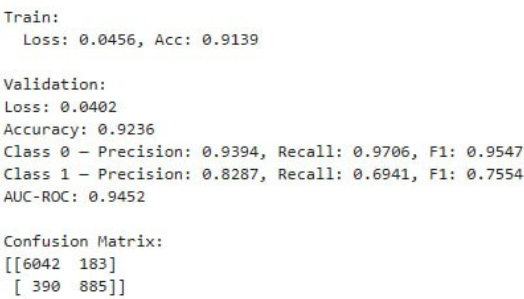

На тесте в кеггл я получил 0.6 и понял, что нужно что то помощнее и поше изучать новые архитектуры. Код ниже это часть юпитера без базовой модельки(код удалял просто)

In [ ]:
!pip install torch scikit-learn pandas tqdm matplotlib seaborn kaggle

import numpy as np
import os
import pandas as pd
from PIL import Image
import math

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim import Optimizer
from torch.amp import autocast, GradScaler

from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rc('font', size=20)


In [ ]:
deepfake_train_path = "/kaggle/input/d/zv3zdochka/ml-intensive-yandex-academy-autumn-2025/dataset/train_images" #пути с кеггл ноутбука
deepfake_test_path = "/kaggle/input/d/zv3zdochka/ml-intensive-yandex-academy-autumn-2025/dataset/test_images"
deepfake_labels_path = "/kaggle/input/d/zv3zdochka/ml-intensive-yandex-academy-autumn-2025/dataset/train_solution.csv"

labels_df = pd.read_csv(deepfake_labels_path)
labels_df.columns = [c.strip() for c in labels_df.columns]
labels_df.columns = ['filename', 'label']

labels_df['filename'] = labels_df['filename'].astype(str).str.strip()

In [ ]:
class DeepFakeDataset(Dataset):
    def __init__(self, root_dir, labels_df=None, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode

        if mode == 'train':
            self.image_names = labels_df['filename'].tolist()
            self.labels = labels_df['label'].astype(int).tolist()
        else:
            self.image_names = sorted([f for f in os.listdir(root_dir)])
            self.labels = None

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        if self.mode == 'train':
            label = self.labels[idx]
            return image, torch.tensor(label, dtype=torch.float).unsqueeze(0)

        return image, img_name


In [ ]:
means = [0.485, 0.456, 0.406]
stds  = [0.229, 0.224, 0.225]

deepfake_transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

deepfake_transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])


In [ ]:
train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    stratify=labels_df["label"],
    random_state=42
)

deepfake_train = DeepFakeDataset(deepfake_train_path, train_df, deepfake_transform_train, 'train')
deepfake_val = DeepFakeDataset(deepfake_train_path, val_df, deepfake_transform_test, 'train')
deepfake_test = DeepFakeDataset(deepfake_test_path, None, deepfake_transform_test, 'test')

class_counts = train_df['label'].value_counts().sort_index().tolist()
print("Class counts:", class_counts)


train_loader = DataLoader(
    deepfake_train,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    deepfake_val,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(deepfake_test, batch_size=64, shuffle=False, num_workers=2)


In [ ]:
def train(model, data_loader, optimizer, loss_fn, scaler):
    model.train()
    total_loss = 0

    for x, y in tqdm(data_loader, desc="Training"):
        x = x.to(device)
        y = y.to(device).float().view(-1, 1)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(data_loader.dataset)


In [ ]:
@torch.inference_mode()
def evaluate(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0
    all_targets = []
    all_probas = []

    for x, y in tqdm(data_loader, desc="Validation"):
        x = x.to(device)
        y = y.to(device).float().view(-1, 1)

        with torch.amp.autocast('cuda'):
            logits = model(x)
            loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        probas = torch.sigmoid(logits).cpu().numpy().flatten()

        all_probas.extend(probas)
        all_targets.extend(y.cpu().numpy().flatten())

    all_targets = np.array(all_targets)
    all_probas = np.array(all_probas)

    precision, recall, thresholds = precision_recall_curve(all_targets, all_probas)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    preds = (all_probas >= best_threshold).astype(int)

    metrics = {
        "loss": total_loss / len(data_loader.dataset),
        "f1_fake": best_f1,
        "threshold": float(best_threshold),
        "roc_auc": roc_auc_score(all_targets, all_probas),
        "confusion_matrix": confusion_matrix(all_targets, preds)
    }

    return metrics


In [ ]:
def plot_stats(train_loss, valid_loss, valid_auc, title):
    plt.figure(figsize=(8, 4))
    plt.title(title + ' — Loss')
    plt.plot(train_loss, label='Train Loss')
    plt.plot(valid_loss, label='Valid Loss')
    plt.legend()
    plt.show()

In [ ]:
def fit(model, train_loader, valid_loader,optimizer, loss_fn, scaler, num_epochs, title="Training"):
    train_loss_history = []
    valid_loss_history = []
    valid_f1_history = []
    valid_auc_history = []
    valid_threshold_history = []
    valid_metrics_history = []

    best_f1 = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss = train(model, train_loader, optimizer, loss_fn, scaler)

        valid_metrics = evaluate(model, valid_loader, loss_fn)

        scheduler.step(valid_metrics["f1_fake"])

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_metrics["loss"])
        valid_f1_history.append(valid_metrics["f1_fake"])
        valid_auc_history.append(valid_metrics["roc_auc"])
        valid_threshold_history.append(valid_metrics["threshold"])
        valid_metrics_history.append(valid_metrics)

        plot_stats.last_cm = valid_metrics["confusion_matrix"]

        if valid_metrics["f1_fake"] > best_f1:
            best_f1 = valid_metrics["f1_fake"]
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, f"best_model_{title}.pth")

        clear_output(wait=True)
        plot_stats(train_loss_history, valid_loss_history, title)

        print("Train:")
        print(f"  Loss: {train_loss:.4f}")

        print("\nValidation:")
        print(f"  Loss:        {valid_metrics['loss']:.4f}")
        print(f"  F1 (fake):   {valid_metrics['f1_fake']:.4f}")
        print(f"  ROC-AUC:     {valid_metrics['roc_auc']:.4f}")
        print(f"  Threshold:   {valid_metrics['threshold']:.3f}")
        print(f"  Best F1 so far: {best_f1:.4f}")
        print("\nConfusion Matrix:")
        print(valid_metrics['confusion_matrix'])


    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "train_loss": train_loss_history,
        "valid_loss": valid_loss_history,
        "valid_f1": valid_f1_history,
        "valid_auc": valid_auc_history,
        "threshold": valid_threshold_history,
        "metrics": valid_metrics_history,
    }


Я вспомнил про residual connection, почитал про концепцию Depthwise Conv свертки, что ее частенько используют для более легких моделей, а так же в целом для дипфейков она хорошо используется, так же я прочитал про SE, его очень часто используют с DWConv, тк он взвешивает полезность каждого канала при использовании этой архитектуры. Я написал реализацию такой модельки, у меня получилось 0.6 миллиона параметров

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.shape
        z = x.mean(dim=(2, 3))
        z = self.fc1(z)
        z = F.relu(z, inplace=True)
        z = self.fc2(z)
        z = torch.sigmoid(z)
        z = z.view(b, c, 1, 1)
        return x * z


class ResidualDWSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.use_skip = (in_ch == out_ch and stride == 1)

        self.dw = nn.Conv2d(
            in_ch, in_ch,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_ch,
            bias=False
        )
        self.dw_bn = nn.BatchNorm2d(in_ch)

        self.pw = nn.Conv2d(
            in_ch, out_ch,
            kernel_size=1,
            bias=False
        )
        self.pw_bn = nn.BatchNorm2d(out_ch)

        self.se = SEBlock(out_ch)
        self.act = nn.LeakyReLU(0.2, inplace=True)

        if not self.use_skip:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = x

        out = self.dw(x)
        out = self.dw_bn(out)
        out = self.act(out)

        out = self.pw(out)
        out = self.pw_bn(out)
        out = self.se(out)

        if self.use_skip:
            out = out + identity
        else:
            out = out + self.skip(identity)

        return self.act(out)



class DeepFakeDWSE(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.stage1 = nn.Sequential(
            ResidualDWSEBlock(32, 32),
            ResidualDWSEBlock(32, 32)
        )

        self.stage2 = nn.Sequential(
            ResidualDWSEBlock(32, 64, stride=2),
            ResidualDWSEBlock(64, 64)
        )

        self.stage3 = nn.Sequential(
            ResidualDWSEBlock(64, 128, stride=2),
            ResidualDWSEBlock(128, 128)
        )

        self.stage4 = nn.Sequential(
            ResidualDWSEBlock(128, 256, stride=2),
            ResidualDWSEBlock(256, 256)
        )

        self.stage5 = nn.Sequential(
            ResidualDWSEBlock(256, 512, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.classifier(x)
        return x


model = DeepFakeDWSE().to(device)
print(f"Модель создана. Параметров: {sum(p.numel() for p in model.parameters()):,}")


In [ ]:
real_count, fake_count = class_counts
pos_weight = torch.tensor([real_count / fake_count], device=device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

scaler = GradScaler()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

In [ ]:
model.to(device)

print("Начинаем обучение...")
fit(model, train_loader, val_loader, optimizer, loss_fn, scaler, num_epochs=25, title="DeepFakeModel")

In [ ]:
state_dict = torch.load("/kaggle/working/best_model_DeepFakeModel.pth")

model = DeepFakeDWSE()
model.load_state_dict(state_dict)
model.to(device)

pos_weight = torch.tensor([class_counts[0] / class_counts[1]], device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-5
)


In [ ]:
fit(model, train_loader, val_loader, optimizer, loss_fn, scaler, num_epochs=15, title="Finetune_DeepFakeModel")


Результатов этой модели на трейне и валидации у меня не осталось, но дала она результат лучше, хотя обучалась меньше(да и весит она меньше, всего 0.6 миллиона параметров). После сабмита я так же получил 0.6 и был удивлен, тк результаты на валидации и трейне были хорошие.

Последняя и самая мощная архитектура, которая была написана мной - архитектура на подобии EfficientNet между B1 и B2, я посмотрел эту архитектуру, изучил реализацию, а именно простенький SiLU(адаптивная активация в общем то), чутка улучшил SE блок, ближе к оригинальному, se_ratio, чтобы менять силу сжатия, так же я решил использовать drop_connectoin, чтобы иногда обнулять какую то часть residual. Так же использую ранее изученные DWConv. На основе всего этого я постоил блок что то на подобии Mobile Inverted Bottleneck Convolution(который используется в Efficient), в отличие от Bottleneck в ResNet в этом блоке происходит сужение, расширение, сужение(поэтому и Inverted). На основе всего этого я построил свою кастомную архитектуру, которая легко расширяется, но, к сожалению, мы начали заниматься проектом мы почти к концу соревнования(конец семместра, зачеты и все такое), успели обучить только модель на 14 миллионов параметров

---

Архитектура состоит из 7 стадий MBConv блоков, постарался написать очень удобной для работы и расширения. Для нашей задачи эта архитектура особенно эффективна из за способности SE блоков и drop connection(данных много, он не должен убивать модель)

In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class SEBlock(nn.Module):
    def __init__(self, in_ch, se_ratio=0.25):
        super().__init__()
        se_ch = max(1, int(in_ch * se_ratio))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_ch, se_ch),
            Swish(),
            nn.Linear(se_ch, in_ch),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y



def drop_connect(x, drop_rate, training):
    if not training or drop_rate == 0.0:
        return x

    keep_prob = 1.0 - drop_rate
    mask = torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
    return x / keep_prob * mask



class MBConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, stride,
                 expand_ratio, se_ratio, drop_rate):
        super().__init__()

        self.use_residual = (in_ch == out_ch and stride == 1)
        hidden_ch = in_ch * expand_ratio
        self.drop_rate = drop_rate

        layers = []

        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_ch, hidden_ch, 1, bias=False),
                nn.BatchNorm2d(hidden_ch, eps=1e-3, momentum=0.01),
                Swish()
            ]

        layers += [
            nn.Conv2d(
                hidden_ch, hidden_ch, k,
                stride=stride, padding=k // 2,
                groups=hidden_ch, bias=False
            ),
            nn.BatchNorm2d(hidden_ch, eps=1e-3, momentum=0.01),
            Swish()
        ]

        layers.append(SEBlock(hidden_ch, se_ratio))

        layers += [
            nn.Conv2d(hidden_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch, eps=1e-3, momentum=0.01)
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)

        if self.use_residual:
            out = x + drop_connect(out, self.drop_rate, self.training)

        return out



class EfficientNetCustom(nn.Module):
    def __init__(self, num_classes=1, dropout=0.3):
        super().__init__()

        width_mult = 1.1
        depth_mult = 1.1

        cfg = [
            (1, 3, 16, 1, 1),
            (6, 3, 24, 2, 2),
            (6, 5, 40, 2, 2),
            (6, 3, 80, 3, 2),
            (6, 5, 112, 3, 1),
            (6, 5, 192, 4, 2),
            (6, 3, 320, 1, 1),
        ]

        def round_ch(ch):
            ch *= width_mult
            return max(8, int(ch + 4) // 8 * 8)

        def round_rep(r):
            return int(math.ceil(r * depth_mult))

        stem_ch = round_ch(32)
        self.stem = nn.Sequential(
            nn.Conv2d(3, stem_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(stem_ch, eps=1e-3, momentum=0.01),
            Swish()
        )

        blocks = []
        in_ch = stem_ch
        total_blocks = sum(round_rep(r) for _, _, _, r, _ in cfg)
        idx = 0

        for exp, k, out, reps, stride in cfg:
            out_ch = round_ch(out)
            for i in range(round_rep(reps)):
                s = stride if i == 0 else 1
                drop = 0.2 * idx / total_blocks
                blocks.append(
                    MBConvBlock(
                        in_ch, out_ch, k, s,
                        expand_ratio=exp,
                        se_ratio=0.25,
                        drop_rate=drop
                    )
                )
                in_ch = out_ch
                idx += 1

        self.blocks = nn.Sequential(*blocks)

        head_ch = round_ch(1280)
        self.head = nn.Sequential(
            nn.Conv2d(in_ch, head_ch, 1, bias=False),
            nn.BatchNorm2d(head_ch, eps=1e-3, momentum=0.01),
            Swish()
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(head_ch, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return self.classifier(x)




model = EfficientNetCustom().to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")


Модель получилась на 14 миллионов параметров, вполне себе, начал ее обучать(вот так прикольно выглядит ее вывод
```
EfficientNetCustom(
  (stem): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Swish()
  )
  (blocks): Sequential(
    (0): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=32, out_features=8, bias=True)
            (1): Swish()
            (2): Linear(in_features=8, out_features=32, bias=True)
            (3): Sigmoid()
          )
        )
        (4): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (5): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (1): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=16, out_features=4, bias=True)
            (1): Swish()
            (2): Linear(in_features=4, out_features=16, bias=True)
            (3): Sigmoid()
          )
        )
        (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (5): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (2): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=96, bias=False)
        (4): BatchNorm2d(96, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=96, out_features=24, bias=True)
            (1): Swish()
            (2): Linear(in_features=24, out_features=96, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(24, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (3): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(144, 144, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=144, bias=False)
        (4): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=144, out_features=36, bias=True)
            (1): Swish()
            (2): Linear(in_features=36, out_features=144, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(144, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(24, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (4): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(144, 144, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=144, bias=False)
        (4): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=144, out_features=36, bias=True)
            (1): Swish()
            (2): Linear(in_features=36, out_features=144, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(144, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(24, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (5): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(144, 144, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), groups=144, bias=False)
        (4): BatchNorm2d(144, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=144, out_features=36, bias=True)
            (1): Swish()
            (2): Linear(in_features=36, out_features=144, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(144, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (6): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(48, 288, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(288, 288, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=288, bias=False)
        (4): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=288, out_features=72, bias=True)
            (1): Swish()
            (2): Linear(in_features=72, out_features=288, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(288, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (7): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(48, 288, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(288, 288, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=288, bias=False)
        (4): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=288, out_features=72, bias=True)
            (1): Swish()
            (2): Linear(in_features=72, out_features=288, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(288, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (8): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(48, 288, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(288, 288, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=288, bias=False)
        (4): BatchNorm2d(288, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=288, out_features=72, bias=True)
            (1): Swish()
            (2): Linear(in_features=72, out_features=288, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(288, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(88, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (9): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(88, 528, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(528, 528, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=528, bias=False)
        (4): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=528, out_features=132, bias=True)
            (1): Swish()
            (2): Linear(in_features=132, out_features=528, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(528, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(88, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (10): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(88, 528, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(528, 528, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=528, bias=False)
        (4): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=528, out_features=132, bias=True)
            (1): Swish()
            (2): Linear(in_features=132, out_features=528, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(528, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(88, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (11): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(88, 528, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(528, 528, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=528, bias=False)
        (4): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=528, out_features=132, bias=True)
            (1): Swish()
            (2): Linear(in_features=132, out_features=528, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(528, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(88, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (12): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(88, 528, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(528, 528, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=528, bias=False)
        (4): BatchNorm2d(528, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=528, out_features=132, bias=True)
            (1): Swish()
            (2): Linear(in_features=132, out_features=528, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(528, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(120, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (13): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(120, 720, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(720, 720, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=720, bias=False)
        (4): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=720, out_features=180, bias=True)
            (1): Swish()
            (2): Linear(in_features=180, out_features=720, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(720, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(120, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (14): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(120, 720, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(720, 720, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=720, bias=False)
        (4): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=720, out_features=180, bias=True)
            (1): Swish()
            (2): Linear(in_features=180, out_features=720, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(720, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(120, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (15): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(120, 720, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(720, 720, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=720, bias=False)
        (4): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=720, out_features=180, bias=True)
            (1): Swish()
            (2): Linear(in_features=180, out_features=720, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(720, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(120, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (16): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(120, 720, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(720, 720, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), groups=720, bias=False)
        (4): BatchNorm2d(720, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=720, out_features=180, bias=True)
            (1): Swish()
            (2): Linear(in_features=180, out_features=720, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(720, 208, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(208, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (17): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(208, 1248, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(1248, 1248, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=1248, bias=False)
        (4): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=1248, out_features=312, bias=True)
            (1): Swish()
            (2): Linear(in_features=312, out_features=1248, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(1248, 208, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(208, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (18): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(208, 1248, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(1248, 1248, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=1248, bias=False)
        (4): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=1248, out_features=312, bias=True)
            (1): Swish()
            (2): Linear(in_features=312, out_features=1248, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(1248, 208, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(208, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (19): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(208, 1248, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(1248, 1248, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=1248, bias=False)
        (4): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=1248, out_features=312, bias=True)
            (1): Swish()
            (2): Linear(in_features=312, out_features=1248, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(1248, 208, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(208, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (20): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(208, 1248, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(1248, 1248, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=1248, bias=False)
        (4): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=1248, out_features=312, bias=True)
            (1): Swish()
            (2): Linear(in_features=312, out_features=1248, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(1248, 208, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(208, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (21): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(208, 1248, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(1248, 1248, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=1248, bias=False)
        (4): BatchNorm2d(1248, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=1248, out_features=312, bias=True)
            (1): Swish()
            (2): Linear(in_features=312, out_features=1248, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(1248, 352, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(352, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
    (22): MBConvBlock(
      (block): Sequential(
        (0): Conv2d(352, 2112, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(2112, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Swish()
        (3): Conv2d(2112, 2112, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=2112, bias=False)
        (4): BatchNorm2d(2112, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (5): Swish()
        (6): SEBlock(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=2112, out_features=528, bias=True)
            (1): Swish()
            (2): Linear(in_features=528, out_features=2112, bias=True)
            (3): Sigmoid()
          )
        )
        (7): Conv2d(2112, 352, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (8): BatchNorm2d(352, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1408, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Swish()
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1408, out_features=1, bias=True)
  )
)
```

In [ ]:
real_count, fake_count = class_counts
pos_weight = torch.tensor([real_count / fake_count], device=device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

scaler = GradScaler()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

In [ ]:
model.to(device)

print("Начинаем обучение...")
train_acc, valid_acc, all_metrics = fit(model, train_loader, val_loader, optimizer, loss_fn, scaler, num_epochs=50, title="DeepFakeModel_new")

Результат после 50 эпох
Train:
  Loss: 0.1340

Validation:
  Loss:        0.3973
  F1 (fake):   0.8598
  ROC-AUC:     0.9782
  Threshold:   0.965
  Best F1 so far: 0.8599

Confusion Matrix:
[[6097  128]
 [ 217 1058]]
 (очень большой трешолд, но, в остальном все выглядит неплохо) по графику было видно, что моделька еще может выдать результат немного лучше

In [ ]:
state_dict = torch.load("/kaggle/working/best_model_DeepFakeModel_new.pth")

model = EfficientNetCustom()
model.load_state_dict(state_dict)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-5)


In [ ]:
fit(model, train_loader, val_loader, optimizer, loss_fn, scaler, num_epochs=15, title="Finetune_DeepFakeModel_new")

Результат Train:
  Loss: 0.0427

Validation:
  Loss:        0.3955
  F1 (fake):   0.8867
  ROC-AUC:     0.9840
  Threshold:   0.971
  Best F1 so far: 0.8873

Confusion Matrix:
[[6124  101]
 [ 179 1096]] улучшился f1, в целом, модель стала чуть лучше

In [ ]:
state_dict = torch.load('/kaggle/working/best_model_Finetune_DeepFakeModel_new.pth', map_location=device)
model = EfficientNetCustom(num_classes=1)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
predictions = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch[0].to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).int().flatten()
        predictions.extend(preds.cpu().numpy())

submission = pd.DataFrame({
    'id': range(len(predictions)),
    'target_feature': predictions
})


submission.to_csv('submission.csv', index=False)

И вновь мои 0.6 на тестовом, после этого я решил не трогать свою часть, тк не знал, в чем проблема и мы пошли объединять все, что у нас получилось.

# **Часть III (Совместная работа)**

На заключительном этапе мы объединили лучшие наработки из наших индивидуальных экспериментов.

**Что взяли от Кирилла:**

* Продвинутую архитектуру на основе EfficientNet с MBConv блоками

* SE-механизмы внимания, которые помогают модели фокусироваться на важных признаках

* Систему drop-connection для лучшей регуляризации

* Оптимизированную структуру с Depthwise свёртками для эффективной обработки

**Что взяли от Маши:**

* Частотный анализ - специальный алгоритм, преобразующий изображения в частотные карты, которые показывают скрытые артефакты генерации

* Гибридную функцию потерь - комбинацию Focal Loss и BCE, которая лучше работает с дисбалансом классов

* Систему подготовки данных с балансировкой и аугментацией

* Мониторинг и визуализацию процесса обучения


### **Техническая реализация:**
Мы модифицировали архитектуру Кирилла, чтобы она принимала 4 входных канала вместо 3. Четвёртый канал - это частотная карта, которая вычислялась для каждого изображения во время обучения. Объединённые данные (RGB + частотный анализ) подавались в улучшенную модель, а гибридная функция потерь помогала фокусироваться на сложных примерах.

**Результат:**
Объединённый подход дал модель, которая превзошла наши индивидуальные результаты. Архитектура Кирилла эффективно извлекала пространственные признаки, а частотный анализ и специальная функция потерь от Маши помогали находить именно те особенности, которые отличают сгенерированные лица от реальных. Это позволило нам получить более высокий скор на тестовых данных.

### **Процесс обучения финальной модели**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import cv2
from torch.amp import autocast, GradScaler
from scipy import fftpack
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
from sklearn.metrics import f1_score, recall_score, precision_score
import math

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/ml-intensive-yandex-academy-autumn-2025.zip"

if os.path.exists(zip_path):
  with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/data')
  print(f"все загрузилось, ура!")
else:
    print("зипка не найдена")

In [ ]:
base = Path('/content/data/dataset')
train_path = base / 'train_images'
test_path = base / 'test_images'
csv_path = base / 'train_solution.csv'

print(f"train images: {train_path.exists()}")
print(f"test images: {test_path.exists()}")
print(f"csv: {csv_path.exists()}")

In [ ]:
labels_df = pd.read_csv(csv_path, header=None, names=['Id', 'target_feature'])

real = sum(labels_df['target_feature'] == 0)
fake = sum(labels_df['target_feature'] == 1)

print(f"настоящих: {real}")
print(f"фейковых: {fake}")
print(f"всего: {real + fake}")

plt.bar(['real', 'fake'], [real, fake])
plt.show()

In [ ]:
class FaceDataset(Dataset):
  def __init__(self, img_dir, labels=None, transform=None, train=True):
    self.img_dir = img_dir
    self.transform = transform
    self.train = train

    if train and labels is not None:
      self.ids = labels['Id'].tolist()
      self.labels = labels['target_feature'].tolist()
    else:
      self.ids = [int(f.stem) for f in img_dir.glob("*.*")
                 if f.suffix in ['.jpg', '.png', '.jpeg']]
      self.labels = None

  def __len__(self):
    return len(self.ids)

  def __getitem__(self, idx):
    img_id = self.ids[idx]

    for ext in ['.jpg', '.png', '.jpeg']:
      path = self.img_dir / f"{img_id}{ext}"
      if path.exists():
        img = Image.open(path).convert('RGB')
        break

    if self.transform:
      img = self.transform(img)

    if self.train:
      return img, torch.tensor(self.labels[idx], dtype=torch.float32)
    return img, img_id

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [ ]:
def compute_frequency_channel(image_tensor):
    batch_size, channels, height, width = image_tensor.shape
    freq_channels = []

    for i in range(batch_size):
        img_gray = image_tensor[i, 1, :, :].cpu().numpy()

        fft = fftpack.fft2(img_gray)
        fft_shifted = fftpack.fftshift(fft)

        magnitude = np.log(np.abs(fft_shifted) + 1)

        magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)

        magnitude_tensor = torch.from_numpy(magnitude).float().unsqueeze(0)
        freq_channels.append(magnitude_tensor)

    return torch.stack(freq_channels).to(image_tensor.device)

In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class SEBlock(nn.Module):
    def __init__(self, in_ch, se_ratio=0.25):
        super().__init__()
        se_ch = max(1, int(in_ch * se_ratio))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_ch, se_ch),
            Swish(),
            nn.Linear(se_ch, in_ch),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


def drop_connect(x, drop_rate, training):
    if not training or drop_rate == 0.0:
        return x

    keep_prob = 1.0 - drop_rate
    mask = torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
    return x / keep_prob * mask


class MBConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, stride,
                 expand_ratio, se_ratio, drop_rate):
        super().__init__()

        self.use_residual = (in_ch == out_ch and stride == 1)
        hidden_ch = in_ch * expand_ratio
        self.drop_rate = drop_rate

        layers = []

        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_ch, hidden_ch, 1, bias=False),
                nn.BatchNorm2d(hidden_ch, eps=1e-3, momentum=0.01),
                Swish()
            ]

        layers += [
            nn.Conv2d(
                hidden_ch, hidden_ch, k,
                stride=stride, padding=k // 2,
                groups=hidden_ch, bias=False
            ),
            nn.BatchNorm2d(hidden_ch, eps=1e-3, momentum=0.01),
            Swish()
        ]

        layers.append(SEBlock(hidden_ch, se_ratio))

        layers += [
            nn.Conv2d(hidden_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch, eps=1e-3, momentum=0.01)
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)

        if self.use_residual:
            out = x + drop_connect(out, self.drop_rate, self.training)

        return out


class EfficientNetCustom(nn.Module):
    def __init__(self, num_classes=1, dropout=0.3):
        super().__init__()

        width_mult = 1.1
        depth_mult = 1.1

        cfg = [
            (1, 3, 16, 1, 1),
            (6, 3, 24, 2, 2),
            (6, 5, 40, 2, 2),
            (6, 3, 80, 3, 2),
            (6, 5, 112, 3, 1),
            (6, 5, 192, 4, 2),
            (6, 3, 320, 1, 1),
        ]

        def round_ch(ch):
            ch *= width_mult
            return max(8, int(ch + 4) // 8 * 8)

        def round_rep(r):
            return int(math.ceil(r * depth_mult))

        stem_ch = round_ch(32)
        self.stem = nn.Sequential(
            nn.Conv2d(4, stem_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(stem_ch, eps=1e-3, momentum=0.01),
            Swish()
        )

        blocks = []
        in_ch = stem_ch
        total_blocks = sum(round_rep(r) for _, _, _, r, _ in cfg)
        idx = 0

        for exp, k, out, reps, stride in cfg:
            out_ch = round_ch(out)
            for i in range(round_rep(reps)):
                s = stride if i == 0 else 1
                drop = 0.2 * idx / total_blocks
                blocks.append(
                    MBConvBlock(
                        in_ch, out_ch, k, s,
                        expand_ratio=exp,
                        se_ratio=0.25,
                        drop_rate=drop
                    )
                )
                in_ch = out_ch
                idx += 1

        self.blocks = nn.Sequential(*blocks)

        head_ch = round_ch(1280)
        self.head = nn.Sequential(
            nn.Conv2d(in_ch, head_ch, 1, bias=False),
            nn.BatchNorm2d(head_ch, eps=1e-3, momentum=0.01),
            Swish()
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(head_ch, num_classes)
        )

    def forward(self, x, freq_channel=None):
        if freq_channel is not None:
            x = torch.cat([x, freq_channel], dim=1)

        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return self.classifier(x)

In [ ]:
train_transform_final = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

val_transform_final = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train_dataset_final = FaceDataset(train_path, train_df, train_transform_final, True)
val_dataset_final = FaceDataset(train_path, val_df, val_transform_final, True)

real_weight = 1.0
fake_weight = len(train_df[train_df['target_feature'] == 0]) / len(train_df[train_df['target_feature'] == 1])

sample_weights_final = []
for idx, row in train_df.iterrows():
    if row['target_feature'] == 1:
        sample_weights_final.append(fake_weight * 1.2)
    else:
        sample_weights_final.append(real_weight)

sampler_final = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights_final),
    num_samples=len(train_df),
    replacement=True)

batch_size_final = 64
train_loader_final = DataLoader(
    train_dataset_final,
    batch_size=batch_size_final,
    sampler=sampler_final,
    num_workers=2,
    pin_memory=True
)

val_loader_final = DataLoader(
    val_dataset_final,
    batch_size=batch_size_final,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"размер батча: {batch_size_final}")
print(f"батчей в train: {len(train_loader_final)}")
print(f"батчей в val: {len(val_loader_final)}")

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, class_weight=6):
        super().__init__()
        self.focal_loss = FocalLoss(alpha=alpha, gamma=gamma)
        self.class_weight = torch.tensor([class_weight]).to(device)

    def forward(self, logits, targets):
        focal = self.focal_loss(logits.squeeze(), targets)

        bce = F.binary_cross_entropy_with_logits(
            logits.squeeze(),
            targets,
            pos_weight=self.class_weight)

        return 0.7 * focal + 0.3 * bce

In [ ]:
model_final = EfficientNetCustom().to(device)

print(f"параметров модели: {sum(p.numel() for p in model_final.parameters()):,}")

In [ ]:
optimizer_final = torch.optim.AdamW(
    model_final.parameters(),
    lr=5e-4,
    weight_decay=1e-4)

scheduler_final = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_final,
    T_0=40,
    T_mult=1,
    eta_min=1e-6)

criterion_final = CombinedLoss(alpha=0.25, gamma=2.0, class_weight=5)

scaler = GradScaler()

train_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
val_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
best_f1_final = 0
best_threshold_final = 0.5
patience_counter = 0
patience_limit = 8

for epoch in range(40):
    model_final.train()
    train_loss = 0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader_final, desc=f"эпоха {epoch+1}")
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        freq_channel = compute_frequency_channel(images)

        with torch.aautocast('cuda'):
            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer_final)
        torch.nn.utils.clip_grad_norm_(model_final.parameters(), max_norm=1.0)

        scaler.step(optimizer_final)
        scaler.update()
        optimizer_final.zero_grad()

        train_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'lr': f'{optimizer_final.param_groups[0]["lr"]:.1e}'})

    model_final.eval()
    val_loss = 0
    val_probs, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader_final:
            images, labels = images.to(device), labels.to(device)
            freq_channel = compute_frequency_channel(images)

            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    train_loss_avg = train_loss / len(train_loader_final)
    val_loss_avg = val_loss / len(val_loader_final)

    thresholds = np.arange(0.3, 0.8, 0.05)
    best_thresh = 0.5
    best_f1 = 0

    for thresh in thresholds:
        preds = (np.array(val_probs) > thresh).astype(float)
        f1 = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    val_preds = (np.array(val_probs) > best_thresh).astype(float)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    val_recall = recall_score(val_labels, val_preds, zero_division=0)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)

    train_preds_binary = (np.array(train_preds) > 0.5).astype(float)
    train_f1 = f1_score(train_labels, train_preds_binary, zero_division=0)
    train_recall = recall_score(train_labels, train_preds_binary, zero_division=0)
    train_precision = precision_score(train_labels, train_preds_binary, zero_division=0)

    train_metrics['loss'].append(train_loss_avg)
    train_metrics['f1'].append(train_f1)
    train_metrics['recall'].append(train_recall)
    train_metrics['precision'].append(train_precision)

    val_metrics['loss'].append(val_loss_avg)
    val_metrics['f1'].append(val_f1)
    val_metrics['recall'].append(val_recall)
    val_metrics['precision'].append(val_precision)

    print(f" loss: {train_loss_avg:.4f} → {val_loss_avg:.4f}")
    print(f" f1:   {train_f1:.4f} → {val_f1:.4f}")
    print(f" recall: {train_recall:.4f} → {val_recall:.4f}")
    print(f" precision: {train_precision:.4f} → {val_precision:.4f}")
    print(f" оптимальный порог: {best_thresh:.2f} (f1: {best_f1:.4f})")

    if val_f1 > best_f1_final:
        best_f1_final = val_f1
        best_threshold_final = best_thresh
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model_final.state_dict(),
            'optimizer_state_dict': optimizer_final.state_dict(),
            'best_f1': best_f1_final,
            'threshold': best_threshold_final,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics
        }, 'best_model_final.pth')

        print(f"сохранена лучшая моделька (f1: {val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"patience: {patience_counter}/{patience_limit}")
        if patience_counter >= patience_limit:
            print(f"ранняя остановка на эпохе {epoch+1}")
            break

    scheduler_final.step()

print(f"лучший f1 на валидации: {best_f1_final:.4f}")
print(f"оптимальный порог: {best_threshold_final:.2f}")

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_metrics['loss'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['loss'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('потери при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(train_metrics['f1'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['f1'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('f1-score')
plt.title('f1-score при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(train_metrics['recall'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['recall'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('recall')
plt.title('recall при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_metrics['precision'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['precision'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('precision')
plt.title('precision при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

После первых 40 эпох обучения мы сохранили модель и проверили её на тестовых данных Kaggle, где она показала результат 0.93. На этом этапе Кирилл осознал, что в его предыдущем коде была ошибка, но сама архитектура оказалась работоспособной. Мы продолжили обучение, добившись следующих промежуточных результатов:

**Лучшие метрики после базового обучения:**

* Loss: 0.0422 → 0.0957

* F1-score: 0.9804 → 0.9009

* Recall: 0.9909 → 0.9388

* Precision: 0.9701 → 0.8660

* Оптимальный порог: 0.75 (F1: 0.9009)

*Первое значение - на тренировочной выборке, второе - на валидационной.*

Параллельно мы скорректировали гиперпараметры: изменили вес класса в функции потерь с 5 на 5.5 и настроили learning rate.

### **Дообучение (10 эпох)**

In [ ]:
model_final = EfficientNetCustom()
checkpoint = torch.load('/content/best_model_final.pth', weights_only=False)
model_final.load_state_dict(checkpoint['model_state_dict'])
model_final.to(device)


In [ ]:
optimizer_final = torch.optim.AdamW(
    model_final.parameters(),
    lr=3e-4,
    weight_decay=1e-5)

scheduler_final = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_final,
    T_0=10,
    T_mult=1,
    eta_min=1e-6)

criterion_final = CombinedLoss(alpha=0.25, gamma=2.0, class_weight=5.5)

scaler = GradScaler()

train_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
val_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
best_f1_final = 0
best_threshold_final = 0.5
patience_counter = 0
patience_limit = 8

for epoch in range(10):
    model_final.train()
    train_loss = 0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader_final, desc=f"эпоха {epoch+1}")
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        freq_channel = compute_frequency_channel(images)

        with torch.amp.autocast('cuda'):
            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer_final)
        torch.nn.utils.clip_grad_norm_(model_final.parameters(), max_norm=1.0)

        scaler.step(optimizer_final)
        scaler.update()
        optimizer_final.zero_grad()

        train_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'lr': f'{optimizer_final.param_groups[0]["lr"]:.1e}'})

    model_final.eval()
    val_loss = 0
    val_probs, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader_final:
            images, labels = images.to(device), labels.to(device)
            freq_channel = compute_frequency_channel(images)

            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    train_loss_avg = train_loss / len(train_loader_final)
    val_loss_avg = val_loss / len(val_loader_final)

    thresholds = np.arange(0.3, 0.8, 0.05)
    best_thresh = 0.5
    best_f1 = 0

    for thresh in thresholds:
        preds = (np.array(val_probs) > thresh).astype(float)
        f1 = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    val_preds = (np.array(val_probs) > best_thresh).astype(float)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    val_recall = recall_score(val_labels, val_preds, zero_division=0)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)

    train_preds_binary = (np.array(train_preds) > 0.5).astype(float)
    train_f1 = f1_score(train_labels, train_preds_binary, zero_division=0)
    train_recall = recall_score(train_labels, train_preds_binary, zero_division=0)
    train_precision = precision_score(train_labels, train_preds_binary, zero_division=0)

    train_metrics['loss'].append(train_loss_avg)
    train_metrics['f1'].append(train_f1)
    train_metrics['recall'].append(train_recall)
    train_metrics['precision'].append(train_precision)

    val_metrics['loss'].append(val_loss_avg)
    val_metrics['f1'].append(val_f1)
    val_metrics['recall'].append(val_recall)
    val_metrics['precision'].append(val_precision)

    print(f" loss: {train_loss_avg:.4f} → {val_loss_avg:.4f}")
    print(f" f1:   {train_f1:.4f} → {val_f1:.4f}")
    print(f" recall: {train_recall:.4f} → {val_recall:.4f}")
    print(f" precision: {train_precision:.4f} → {val_precision:.4f}")
    print(f" оптимальный порог: {best_thresh:.2f} (f1: {best_f1:.4f})")

    if val_f1 > best_f1_final:
        best_f1_final = val_f1
        best_threshold_final = best_thresh
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model_final.state_dict(),
            'optimizer_state_dict': optimizer_final.state_dict(),
            'best_f1': best_f1_final,
            'threshold': best_threshold_final,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics
        }, 'best_model_final_2.pth')

        print(f"сохранена лучшая моделька (f1: {val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"patience: {patience_counter}/{patience_limit}")
        if patience_counter >= patience_limit:
            print(f"ранняя остановка на эпохе {epoch+1}")
            break

    scheduler_final.step()

print(f"лучший f1 на валидации: {best_f1_final:.4f}")
print(f"оптимальный порог: {best_threshold_final:.2f}")

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_metrics['loss'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['loss'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('потери при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(train_metrics['f1'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['f1'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('f1-score')
plt.title('f1-score при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(train_metrics['recall'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['recall'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('recall')
plt.title('recall при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_metrics['precision'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['precision'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('precision')
plt.title('precision при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

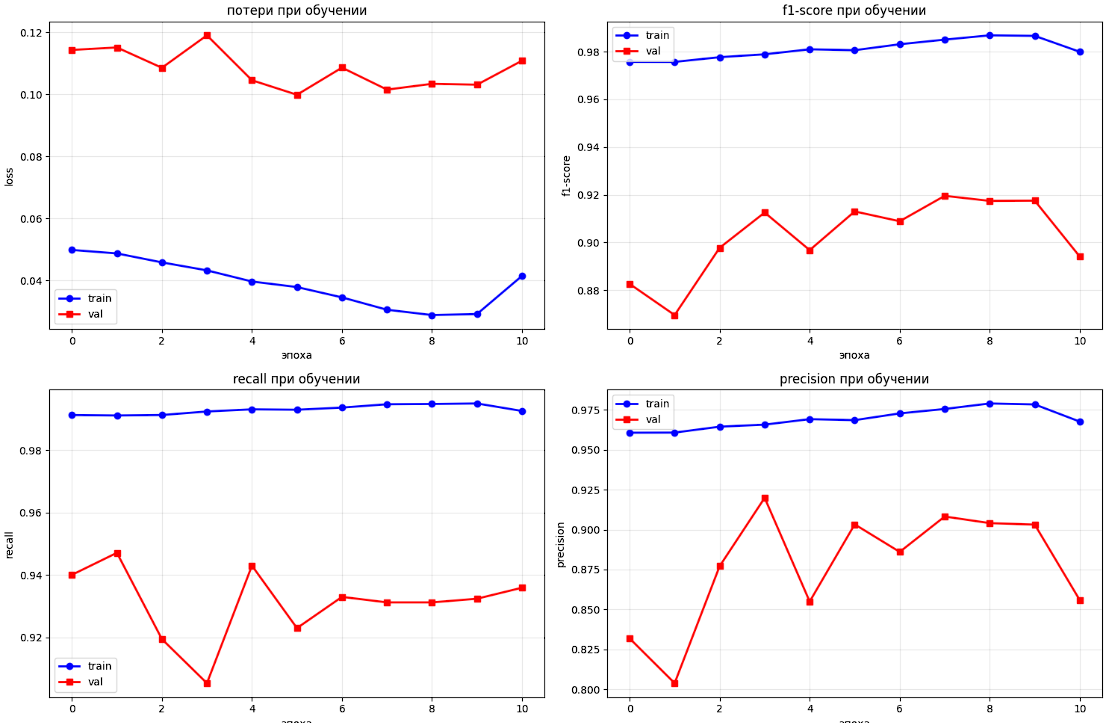

После дополнительных 10 эпох метрики улучшились:

* Loss: 0.0306 → 0.1015

* F1-score: 0.9850 → 0.9195

* Recall: 0.9946 → 0.9312

* Precision: 0.9756 → 0.9082

*Оптимальный порог: 0.75 (F1: 0.9195)

На тестовых данных Kaggle модель показала результат 0.945 (при пороге 0.75), а с подобранным порогом - до 0.95.

После мы финально решили дообучить модельку, прогнали еще 20 эпох, но изменили опять вес класса и LR.


### **Финальное дообучение (20 эпох)**

In [ ]:
model_final = EfficientNetCustom()
checkpoint = torch.load('/content/best_model_final_2.pth', weights_only=False)
model_final.load_state_dict(checkpoint['model_state_dict'])
model_final.to(device)

In [ ]:
optimizer_final = torch.optim.AdamW(
    model_final.parameters(),
    lr=1.5e-4,
    weight_decay=1e-5)

scheduler_final = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_final,
    T_0=20,
    T_mult=1,
    eta_min=1e-6)

criterion_final = CombinedLoss(alpha=0.25, gamma=2.0, class_weight=6)

scaler = GradScaler()

train_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
val_metrics = {
    'loss': [], 'f1': [], 'recall': [], 'precision': []
}
best_f1_final = 0
best_threshold_final = 0.5
patience_counter = 0
patience_limit = 8

for epoch in range(20):
    model_final.train()
    train_loss = 0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader_final, desc=f"эпоха {epoch+1}")
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        freq_channel = compute_frequency_channel(images)

        with torch.amp.autocast('cuda'):
            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer_final)
        torch.nn.utils.clip_grad_norm_(model_final.parameters(), max_norm=1.0)

        scaler.step(optimizer_final)
        scaler.update()
        optimizer_final.zero_grad()

        train_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            pbar.set_postfix({
                'loss': f'{loss.item():.3f}',
                'lr': f'{optimizer_final.param_groups[0]["lr"]:.1e}'})

    model_final.eval()
    val_loss = 0
    val_probs, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader_final:
            images, labels = images.to(device), labels.to(device)
            freq_channel = compute_frequency_channel(images)

            outputs = model_final(images, freq_channel)
            loss = criterion_final(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    train_loss_avg = train_loss / len(train_loader_final)
    val_loss_avg = val_loss / len(val_loader_final)

    thresholds = np.arange(0.3, 0.8, 0.05)
    best_thresh = 0.5
    best_f1 = 0

    for thresh in thresholds:
        preds = (np.array(val_probs) > thresh).astype(float)
        f1 = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    val_preds = (np.array(val_probs) > best_thresh).astype(float)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    val_recall = recall_score(val_labels, val_preds, zero_division=0)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)

    train_preds_binary = (np.array(train_preds) > 0.5).astype(float)
    train_f1 = f1_score(train_labels, train_preds_binary, zero_division=0)
    train_recall = recall_score(train_labels, train_preds_binary, zero_division=0)
    train_precision = precision_score(train_labels, train_preds_binary, zero_division=0)

    train_metrics['loss'].append(train_loss_avg)
    train_metrics['f1'].append(train_f1)
    train_metrics['recall'].append(train_recall)
    train_metrics['precision'].append(train_precision)

    val_metrics['loss'].append(val_loss_avg)
    val_metrics['f1'].append(val_f1)
    val_metrics['recall'].append(val_recall)
    val_metrics['precision'].append(val_precision)

    print(f" loss: {train_loss_avg:.4f} → {val_loss_avg:.4f}")
    print(f" f1:   {train_f1:.4f} → {val_f1:.4f}")
    print(f" recall: {train_recall:.4f} → {val_recall:.4f}")
    print(f" precision: {train_precision:.4f} → {val_precision:.4f}")
    print(f" оптимальный порог: {best_thresh:.2f} (f1: {best_f1:.4f})")

    if val_f1 > best_f1_final:
        best_f1_final = val_f1
        best_threshold_final = best_thresh
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model_final.state_dict(),
            'optimizer_state_dict': optimizer_final.state_dict(),
            'best_f1': best_f1_final,
            'threshold': best_threshold_final,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics
        }, 'best_model_final_3.pth')

        print(f"сохранена лучшая моделька (f1: {val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"patience: {patience_counter}/{patience_limit}")
        if patience_counter >= patience_limit:
            print(f"ранняя остановка на эпохе {epoch+1}")
            break

    scheduler_final.step()

print(f"лучший f1 на валидации: {best_f1_final:.4f}")
print(f"оптимальный порог: {best_threshold_final:.2f}")

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(train_metrics['loss'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['loss'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('потери при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(train_metrics['f1'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['f1'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('f1-score')
plt.title('f1-score при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(train_metrics['recall'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['recall'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('recall')
plt.title('recall при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(train_metrics['precision'], 'b-', linewidth=2, marker='o', label='train')
plt.plot(val_metrics['precision'], 'r-', linewidth=2, marker='s', label='val')
plt.xlabel('эпоха')
plt.ylabel('precision')
plt.title('precision при обучении')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
checkpoint = torch.load('best_model_final_3.pth', weights_only=False)
model_final.load_state_dict(checkpoint['model_state_dict'])
best_threshold = 0.90

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

test_dataset = FaceDataset(test_path, transform=test_transform, train=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

model_final.eval()
test_predictions = []
test_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="тестирование"):
        images = images.to(device)

        freq_channel = compute_frequency_channel(images)

        outputs = model_final(images, freq_channel)
        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > best_threshold).float().cpu().numpy()

        test_predictions.extend(preds.astype(int))
        test_ids.extend(ids.cpu().numpy())

submission5 = pd.DataFrame({
    'id': test_ids,
    'target_feature': test_predictions })

submission5 = submission5.sort_values('id').reset_index(drop=True)

output_file = 'submission5.csv'
submission5.to_csv(output_file, index=False)

print(f"файл {output_file} сохранен")

Мы провели заключительный этап обучения на 20 эпохах, снова скорректировав вес класса и learning rate.

**Лучший результат на валидации:**

* Loss: 0.0209 → 0.1182

* F1-score: 0.9901 → 0.9323

* Recall: 0.9961 → 0.9359

* Precision: 0.9842 → 0.9288

* Оптимальный порог: 0.70 (F1: 0.9323)

На тесте Kaggle с порогом 0.9 мы получили Public Score: 0.961. После открытия приватной оценки итоговый результат составил 0.95276.

Для самостоятельно реализованной модели с 14 миллионами параметров это вполне достойный результат, хотя он немного уступает предобученной EfficientNetB2 (7 миллионов параметров).

### **Примечание о весах модели:**
Мы сохранили веса после первых 40 эпох обучения и после второго этапа дообучения (15 эпох). К сожалению, веса финальной модели (третьего этапа дообучения) не были скачаны на локальный компьютер, так как все сабмиты выполнялись в последние минуты соревнования.  После сильной радости от результата 0.961, мы завершили сессию работы, закрыли ноутбук и пошли кушать, так и не сохранив веса третьей модели, которые в итоге были утеряны.

По этой причине мы прилагаем веса второго этапа дообучения. При необходимости мы можем повторно обучить модель после 20 декабря, когда восстановится доступ к бесплатным вычислительным ресурсам (Kaggle и Colab в данный момент исчерпали лимиты). Приносим извинения за эту ситуацию.

### **Веса обученной модели:**
https://drive.google.com/file/d/1XNnRxVWkGSUI2Th_tspLmIorL-m5OfMu/view?usp=sharing

Файл с весами модели имеет формат .pth. После скачивания файла с Google Drive вы можете загрузить и проанализировать веса с помощью кода ниже.

In [ ]:
import torch

weights = torch.load('сюда свой путь', map_location='cpu')


if isinstance(weights, dict) and 'state_dict' in weights:
    weights = weights['state_dict']

for name, param in weights.items():
    print(f"\n{'='*60}")
    print(f"Слой: {name}")
    print(f"Форма: {param.shape}")
    print(f"Значения:")
    print(param)

### **Итог:**
В ходе проекта наша команда самостоятельно изучила множество современных методов и приёмов для задачи распознавания дипфейков, исследовала популярные архитектуры и реализовала собственную. Объединив наши лучшие наработки, мы добились результата, превосходящего индивидуальные достижения.

Благодарим организаторов за увлекательное соревнование и познавательный курс, а также нашего ментора за поддержку на протяжении всего проекта!